<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Copy_of_2_K_Nearest_Neigbours_Classification_(for_Slides).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

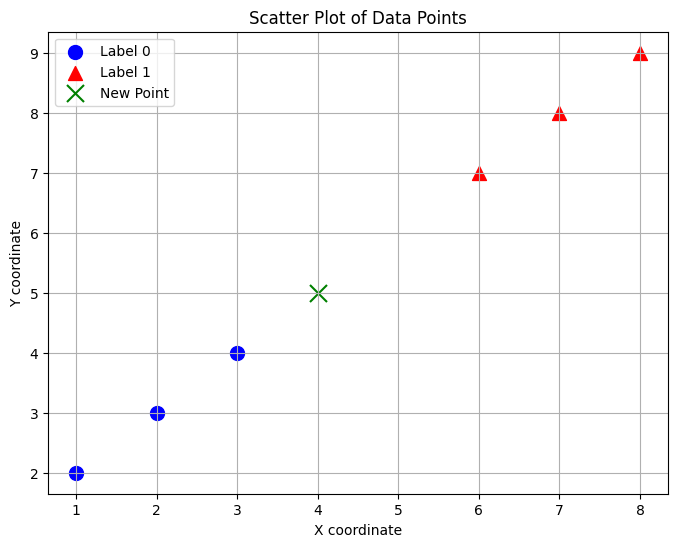

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data points and labels
data_points = np.array([[1, 2], [2, 3], [3, 4], [6, 7], [7, 8], [8, 9]])
labels = np.array([0, 0, 0, 1, 1, 1])
new_point = np.array([4, 5])

# Separate data points by their labels
class0 = data_points[labels == 0]
class1 = data_points[labels == 1]

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(class0[:, 0], class0[:, 1], color='blue', label='Label 0', s=100, marker='o')  # Class 0
plt.scatter(class1[:, 0], class1[:, 1], color='red', label='Label 1', s=100, marker='^')  # Class 1
plt.scatter(new_point[0], new_point[1], color='green', label='New Point', s=150, marker='x')  # New point

# Adding labels, title and legend
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title('Scatter Plot of Data Points')
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()


In [ ]:
from sklearn.metrics import pairwise_distances
from collections import Counter

def kNN_Classify(new_point, data_points, labels, k, distance_metric='euclidean'):
    # Step 1: Calculate distances using pairwise_distances
    distances = pairwise_distances(data_points, new_point, metric=distance_metric).ravel()

    # Step 2 & 3: Sort distances and select k nearest neighbors
    k_nearest_neighbors_indices = np.argsort(distances)[:k]
    k_nearest_labels = labels[k_nearest_neighbors_indices]

    # Step 4: Perform majority vote
    most_common = Counter(k_nearest_labels).most_common(1)

    # Step 5: Determine the predicted class
    predicted_class = most_common[0][0]

    return predicted_class

In [ ]:
# Example usage
data_points = np.array([[1, 2], [2, 3], [3, 4], [6, 7], [7, 8], [8, 9]])
labels = np.array([0, 0, 0, 1, 1, 1])  # 0 and 1 are class labels
new_point = np.array([[4, 5]])
k = 3
distance_metric = 'euclidean'  # Can be 'euclidean', 'manhattan', 'cosine', etc.

# Classify the new point
predicted_class = kNN_Classify(new_point, data_points, labels, k, distance_metric)
print("Predicted Class:", predicted_class)

Predicted Class: 0


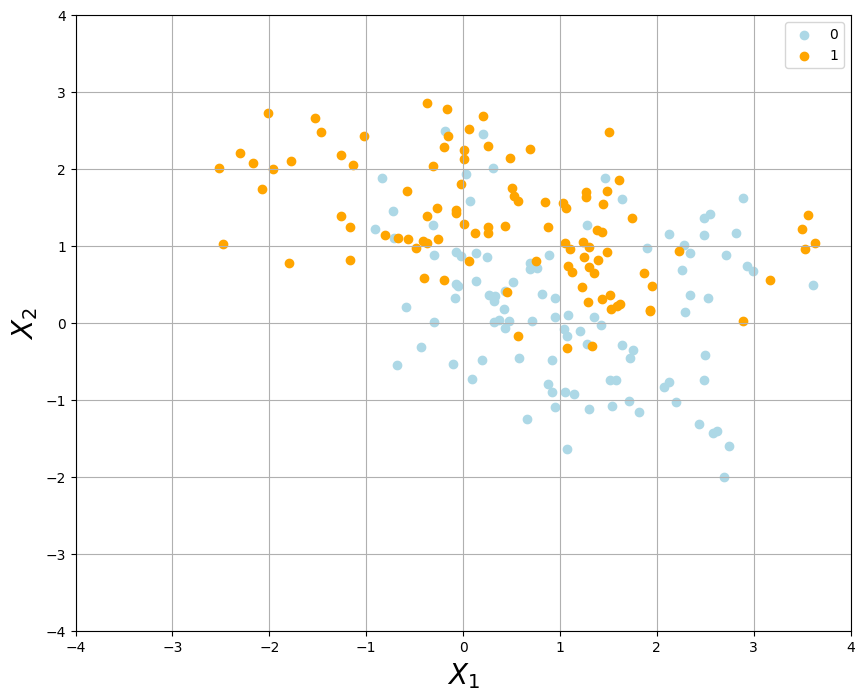

In [ ]:
import pandas as pd

# URL for our dataset, mixture-example.csv
URL = "https://drive.google.com/file/d/1l0QDFXeyrelvjXlyhnj4ppP_SSTABIKp/view?usp=sharing"
FILE_PATH = "https://drive.google.com/uc?export=download&id=" + URL.split("/")[-2]

data = pd.read_csv(FILE_PATH)

# Filter data by labels
data_0 = data[data['Label'] == 0]
data_1 = data[data['Label'] == 1]

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(data_0['X'], data_0['Y'], color='lightblue', label='0', marker='o')
plt.scatter(data_1['X'], data_1['Y'], color='orange', label='1', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Load the dataset
# data = pd.read_csv('/path/to/mixture-example.csv')  # Adjust path as necessary

# Separate features and labels
X = data[['X', 'Y']].values  # assuming 'X' and 'Y' are your features
y = data['Label'].values  # assuming 'Label' is your label column

# First, split the data into train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Then split the temp data into validation (50% of 40% => 20% of total) and test (remaining 50% of 40% => 20% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Checking the proportion of each set
print("Training Set Size:", len(X_train))
print("Validation Set Size:", len(X_val))
print("Test Set Size:", len(X_test))


Training Set Size: 120
Validation Set Size: 40
Test Set Size: 40


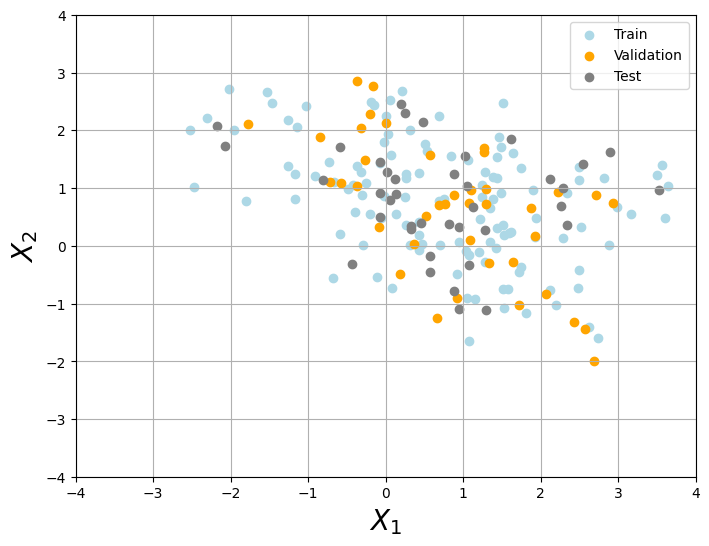

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:,0], X_train[:,1], color='lightblue', label='Train', marker='o')
plt.scatter(X_val[:,0], X_val[:,1], color='orange', label='Validation', marker='o')
plt.scatter(X_test[:,0], X_test[:,1], color='grey', label='Test', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

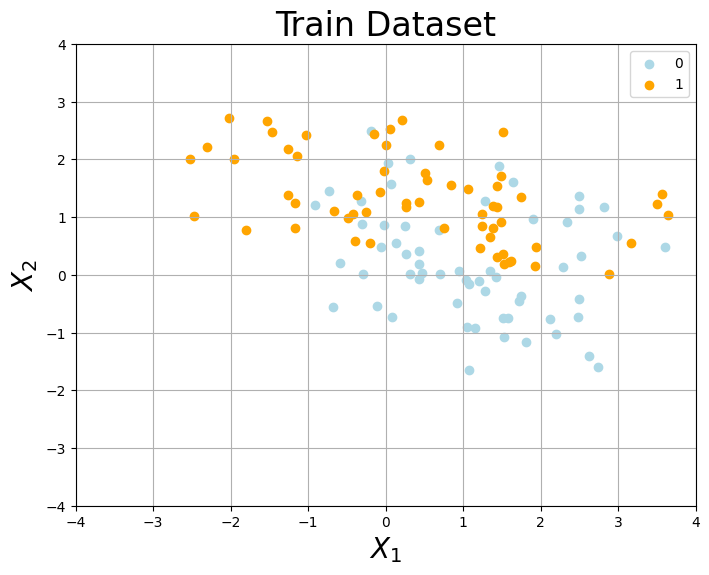

In [ ]:
# Plotting

X = X_train
y = y_train
title = "Train Dataset"

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0][:,0], X[y==0][:,1], color='lightblue', label='0', marker='o')
plt.scatter(X[y==1][:,0], X[y==1][:,1], color='orange', label='1', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.title(title, fontsize=24)
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Define k and the distance metric
k = 5
distance_metric = 'euclidean'

# Create an instance of KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metric)

# Fit the model on the training data
knn.fit(X_train, y_train)

# Predict the labels on the validation set
predictions = knn.predict(X_val)

# Calculate the accuracy of the predictions
accuracy = accuracy_score(y_val, predictions)
print("Accuracy of the k-NN classifier on the validation set:", accuracy)


Accuracy of the k-NN classifier on the validation set: 0.85


In [ ]:
from sklearn.metrics import pairwise_distances
from collections import Counter

def kNN_Classify(new_points, data_points, labels, k, distance_metric='euclidean'):
    predictions = []
    for new_point in new_points:
        # Calculate distances
        distances = pairwise_distances(data_points, [new_point], metric=distance_metric).ravel()

        # Get indices of k nearest neighbors
        k_nearest_indices = np.argsort(distances)[:k]
        k_nearest_labels = labels[k_nearest_indices]

        # Perform majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        predicted_class = most_common[0][0]
        predictions.append(predicted_class)

    return predictions

In [ ]:
from sklearn.metrics import accuracy_score

# Define k and the distance metric
k = 5
distance_metric = 'euclidean'

# Call the kNN_Classify function to predict the validation set
predictions = kNN_Classify(X_val, X_train, y_train, k, distance_metric)

# Calculate the accuracy of the predictions
accuracy = accuracy_score(y_val, predictions)
print("Accuracy of the k-NN classifier on the validation set:", accuracy)

Accuracy of the k-NN classifier on the validation set: 0.85


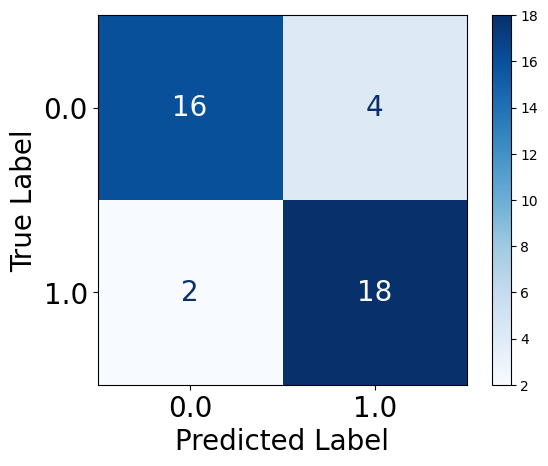

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fontsize = 20
ax = ConfusionMatrixDisplay.from_predictions(y_val, predictions, cmap=plt.cm.Blues)
#plt.plot()
for entries in ax.text_.ravel():
    entries.set_fontsize(fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Predicted Label", fontsize=fontsize)
plt.ylabel("True Label", fontsize=fontsize)
plt.show()


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
# Define your CustomKNNClassifier following scikit-learn conventions...

class CustomKNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        self.X_train_ = X
        self.y_train_ = y
        return self

    def predict(self, X):
        # Your custom predict logic here
        y_pred = []
        for x in X:
            # Calculate distances
            distances = pairwise_distances(self.X_train_, [x], metric=self.distance_metric).ravel()

            # Get indices of k nearest neighbors
            k_nearest_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train_[k_nearest_indices]

            # Perform majority vote
            most_common = Counter(k_nearest_labels).most_common(1)
            predicted_class = most_common[0][0]
            y_pred.append(predicted_class)

        return np.array(y_pred)


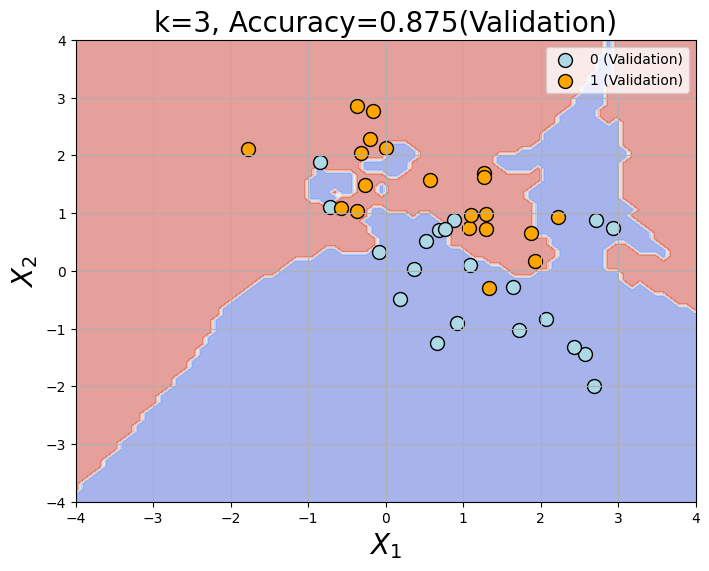

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

k = 3
distance_metric = "euclidean"

xv, yv = np.meshgrid(np.linspace(-4,4,400), np.linspace(-4,4,400))

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    estimator=knn,
    X=np.vstack((xv.ravel(), yv.ravel())).T,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['0', '1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
#ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('$X_1$', fontsize=20)
ax.set_ylabel('$X_2$', fontsize=20)
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.axis([-4, 4, -4, 4])
plt.title("k=" + str(k) + ", Accuracy=" + str(accuracy_score(y_val, knn.predict(X_val))) + "(Validation)", fontsize=20)
plt.grid()
plt.show()

In [ ]:
xv, yv = np.meshgrid(np.linspace(-4,4,400), np.linspace(-4,4,400))
np.vstack((xv.ravel(), yv.ravel())).T

array([[-4.        , -4.        ],
       [-3.97994987, -4.        ],
       [-3.95989975, -4.        ],
       ...,
       [ 3.95989975,  4.        ],
       [ 3.97994987,  4.        ],
       [ 4.        ,  4.        ]])

In [ ]:
neighbours = np.arange(1,31)
validation_scores = []
train_scores = []
for k in neighbours :
    knn = CustomKNNClassifier(k=k, distance_metric="euclidean")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)

    validation_scores.append(accuracy_score(y_val, knn.predict(X_val)))
    train_scores.append(accuracy_score(y_train, knn.predict(X_train)))

validation_scores = np.array(validation_scores)
train_scores = np.array(train_scores)

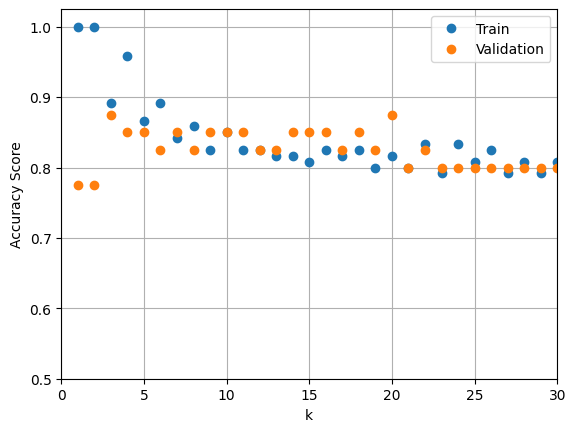

In [ ]:
plt.plot(neighbours, train_scores, 'o', label="Train")
plt.plot(neighbours, validation_scores, 'o', label="Validation")
plt.xlabel('k')
plt.ylabel('Accuracy Score')
plt.axis([0, 30, 0.5, 1.025])
plt.grid()
plt.legend()
plt.show()

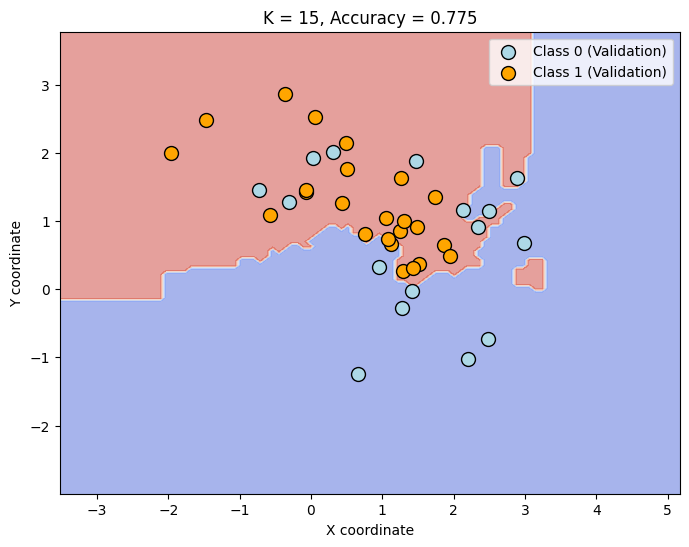

In [ ]:
k = 15
distance_metric = "manhattan"

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

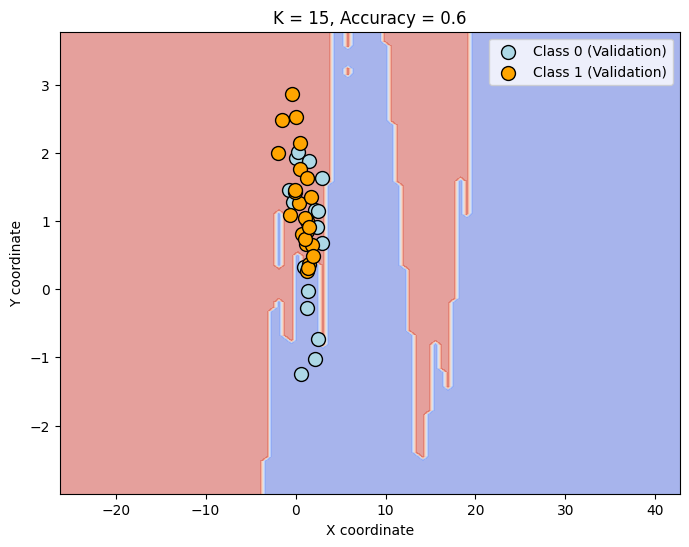

In [ ]:
k = 15
distance_metric = "euclidean"
scale = np.array([10, 1])

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(scale*X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    scale*X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(scale*X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

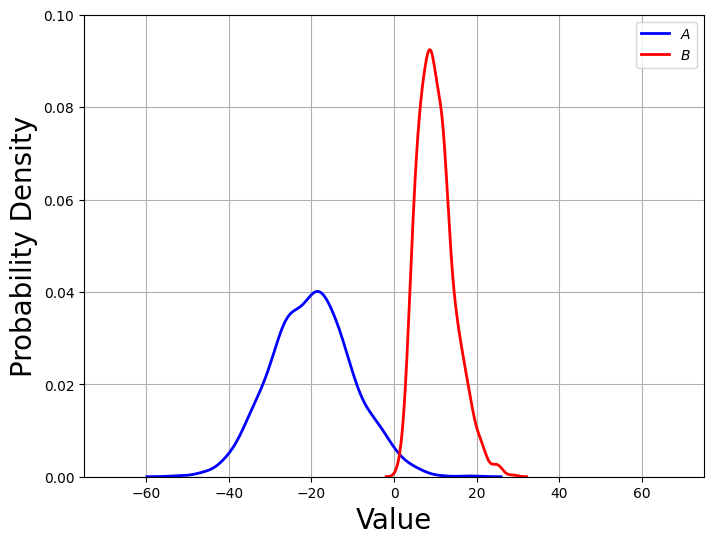

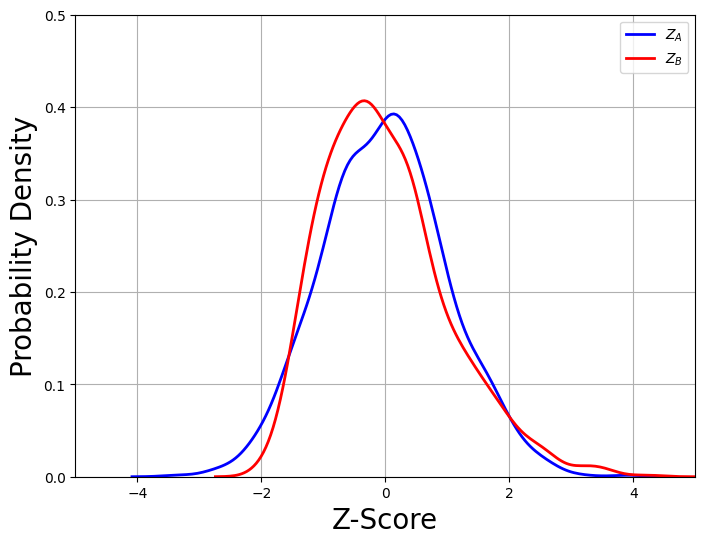

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate and standardize data
data_normal = np.random.normal(loc=-20, scale=10, size=1000)
data_gamma = np.random.gamma(shape=5, scale=2, size=1000)
z_normal = (data_normal - np.mean(data_normal)) / np.std(data_normal)
z_gamma = (data_gamma - np.mean(data_gamma)) / np.std(data_gamma)

# Plotting using seaborn for easier KDE
plt.figure(figsize=(8, 6))
sns.kdeplot(data_normal, label='$A$', color='blue', lw=2)
sns.kdeplot(data_gamma, label='$B$', color='red', lw=2)
plt.xlabel("Value", fontsize=20)
plt.ylabel("Probability Density", fontsize=20)
plt.axis([-75, 75, 0, 0.1])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.kdeplot(z_normal, label='$Z_{A}$', color='blue', lw=2)
sns.kdeplot(z_gamma, label='$Z_{B}$', color='red', lw=2)
plt.xlabel("Z-Score", fontsize=20)
plt.ylabel("Probability Density", fontsize=20)
plt.axis([-5, 5, 0, 0.5])
plt.legend()
plt.grid()
plt.show()


In [ ]:
np.mean(data_normal), np.std(data_normal), np.mean(data_gamma), np.std(data_gamma)

(-19.806679441776744, 9.787262077473542, 10.16331996051392, 4.401450303905136)

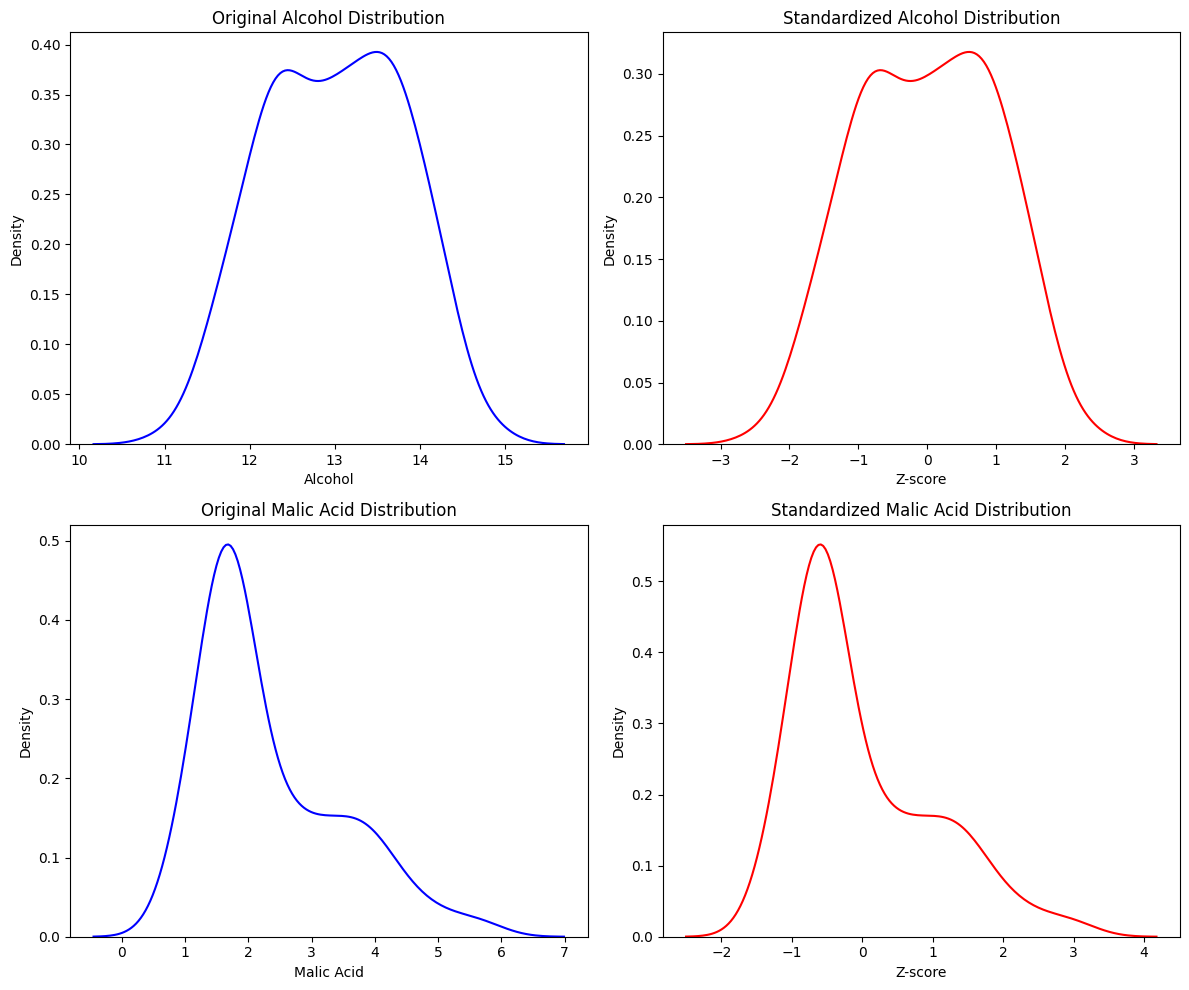

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a standard scaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up GridSearchCV to find the optimal k for k-NN
param_grid = {'n_neighbors': list(range(1, 31))}

# Grid search on the original data
knn_gs_original = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_original.fit(X_train, y_train)
best_k_original = knn_gs_original.best_params_['n_neighbors']
best_score_original = knn_gs_original.best_score_

# Evaluate on test data
predictions_original = knn_gs_original.predict(X_test)
accuracy_original = accuracy_score(y_test, predictions_original)

# Grid search on the scaled data
knn_gs_scaled = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_scaled.fit(X_train_scaled, y_train)
best_k_scaled = knn_gs_scaled.best_params_['n_neighbors']
best_score_scaled = knn_gs_scaled.best_score_

# Evaluate on test data
predictions_scaled = knn_gs_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, predictions_scaled)

# Output the results
print(f"Optimal k on original data: {best_k_original}, Validation Score: {best_score_original:.2f}, Test Accuracy: {accuracy_original:.2f}")
print(f"Optimal k on scaled data: {best_k_scaled}, Validation Score: {best_score_scaled:.2f}, Test Accuracy: {accuracy_scaled:.2f}")


In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a standard scaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up GridSearchCV to find the optimal k for k-NN
param_grid = {'n_neighbors': list(range(1, 31))}

# Grid search on the original data
knn_gs_original = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_original.fit(X_train, y_train)
best_k_original = knn_gs_original.best_params_['n_neighbors']
best_score_original = knn_gs_original.best_score_

# Evaluate on test data
predictions_original = knn_gs_original.predict(X_test)
accuracy_original = accuracy_score(y_test, predictions_original)

# Grid search on the scaled data
knn_gs_scaled = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_scaled.fit(X_train_scaled, y_train)
best_k_scaled = knn_gs_scaled.best_params_['n_neighbors']
best_score_scaled = knn_gs_scaled.best_score_

# Evaluate on test data
predictions_scaled = knn_gs_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, predictions_scaled)

# Output the results
print(f"Optimal k on original data: {best_k_original}, Validation Score: {best_score_original:.2f}, Test Accuracy: {accuracy_original:.2f}")
print(f"Optimal k on scaled data: {best_k_scaled}, Validation Score: {best_score_scaled:.2f}, Test Accuracy: {accuracy_scaled:.2f}")


Optimal k on original data: 17, Validation Score: 0.73, Test Accuracy: 0.78
Optimal k on scaled data: 13, Validation Score: 0.96, Test Accuracy: 0.97


In [ ]:
X_train.shape

(142, 13)

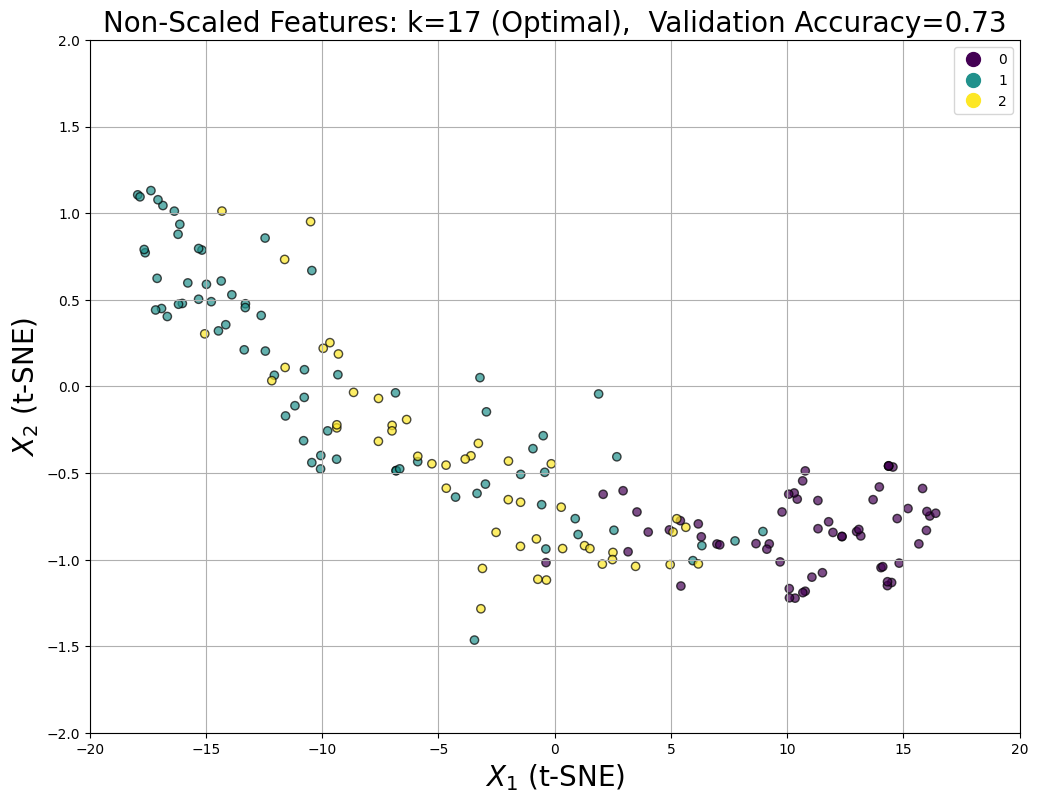

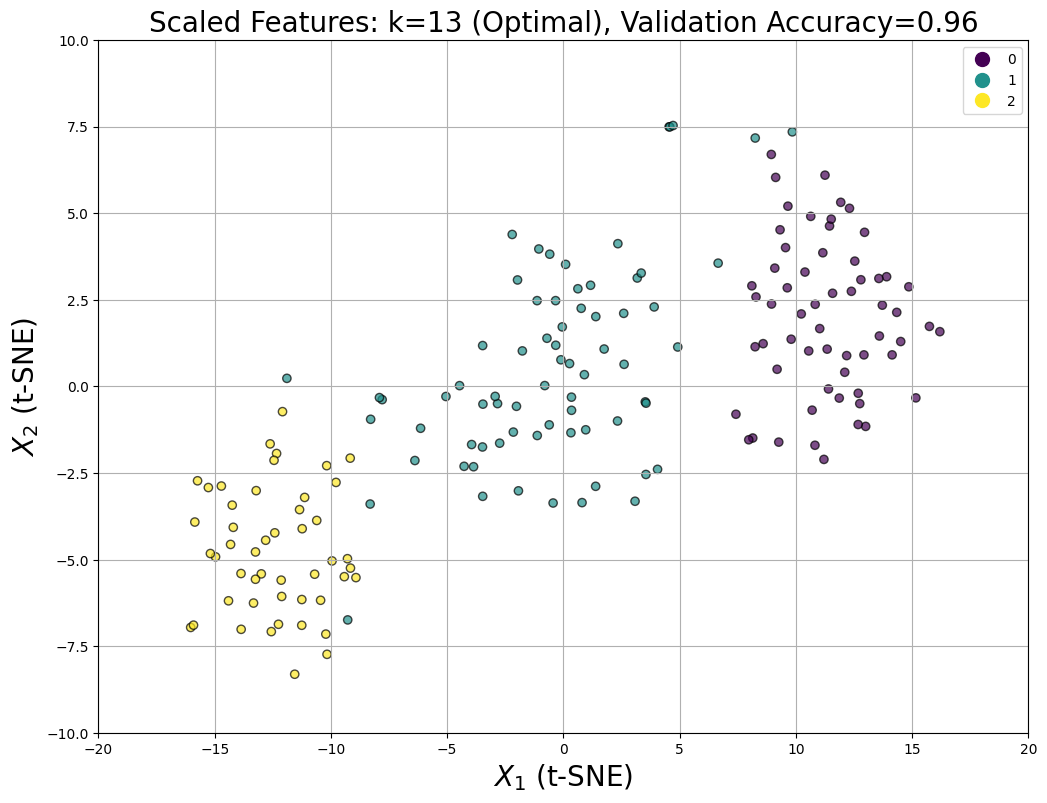

In [ ]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target
target_names = data.target_names

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE on the original data
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# t-SNE on the scaled data
tsne_scaled = TSNE(n_components=2, random_state=42)
X_tsne_scaled = tsne_scaled.fit_transform(X_scaled)

# Mapping colors to labels
cmap = plt.cm.viridis
norm = plt.Normalize(y.min(), y.max())

# Figure 1: t-SNE on Original Data
plt.figure(figsize=(12, 9))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap=cmap, edgecolor='k', alpha=0.7, norm=norm)
plt.title('Non-Scaled Features: k=17 (Optimal),  Validation Accuracy=0.73', fontsize=20)
plt.xlabel('$X_1$ (t-SNE)', fontsize=20)
plt.ylabel('$X_2$ (t-SNE)', fontsize=20)
plt.axis([-20, 20, -2, 2])
plt.grid()
# Create a legend:
handles = [plt.Line2D([], [], marker='o', color=cmap(norm(i)), linestyle='', markersize=10, label=name[-1]) for i, name in enumerate(target_names)]
plt.legend(handles=handles)
plt.show()

# Figure 2: t-SNE on Scaled Data
plt.figure(figsize=(12, 9))
scatter = plt.scatter(X_tsne_scaled[:, 0], X_tsne_scaled[:, 1], c=y, cmap=cmap, edgecolor='k', alpha=0.7, norm=norm)
plt.title('Scaled Features: k=13 (Optimal), Validation Accuracy=0.96', fontsize=20)
plt.xlabel('$X_1$ (t-SNE)', fontsize=20)
plt.ylabel('$X_2$ (t-SNE)', fontsize=20)
plt.axis([-20, 20, -10, 10])
plt.grid()
# Create a legend:
handles = [plt.Line2D([], [], marker='o', color=cmap(norm(i)), linestyle='', markersize=10, label=name[-1]) for i, name in enumerate(target_names)]
plt.legend(handles=handles)
plt.show()


In [ ]:
name

NameError: name 'name' is not defined

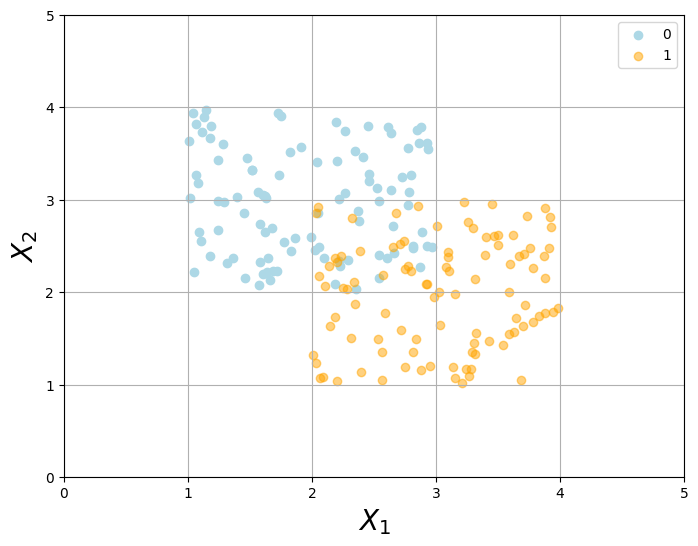

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Define means for two classes
center_class_0 = [2, 3]
center_class_1 = [3, 2]

# Define the range for uniform distribution around the means
range_class_0 = 1
range_class_1 = 1

# Generate uniform data around these means for each class
# Class 0 points
data_class_0 = np.random.uniform(low=np.array(center_class_0) - range_class_0,
                                 high=np.array(center_class_0) + range_class_0, size=(100, 2))
# Class 1 points
data_class_1 = np.random.uniform(low=np.array(center_class_1) - range_class_1,
                                 high=np.array(center_class_1) + range_class_1, size=(100, 2))

# Combine the data into a single array
data_points = np.vstack((data_class_0, data_class_1))
labels = np.array([0]*100 + [1]*100)  # 100 points in class 0, 100 points in class 1

# Plot the generated data
plt.figure(figsize=(8, 6))
plt.scatter(data_class_0[:, 0], data_class_0[:, 1], color='lightblue', marker='o', label='0', alpha=1.0)
plt.scatter(data_class_1[:, 0], data_class_1[:, 1], color='orange', marker='o', label='1', alpha=0.5)
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([0, 5, 0, 5])
plt.legend()
plt.grid(True)
plt.show()


In [2]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# URL for our dataset, mixture-example.csv
URL = "https://drive.google.com/file/d/1Ls7f9OWKgeWswFR4EZ5eeoohfY9PACRT/view?usp=sharing"
FILE_PATH = "https://drive.google.com/uc?export=download&id=" + URL.split("/")[-2]

data = pd.read_csv(FILE_PATH)

# Separate features and labels
X = data[['x1', 'x2']].values  # assuming 'X' and 'Y' are your features
y = data['y'].values  # assuming 'Label' is your label column

# First, split the data into train (60%) and temp (40%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Checking the proportion of each set
print("Training Set Size:", len(X_train))
print("Test Set Size:", len(X_test))

X_train = X
y_train = y

Training Set Size: 21
Test Set Size: 10


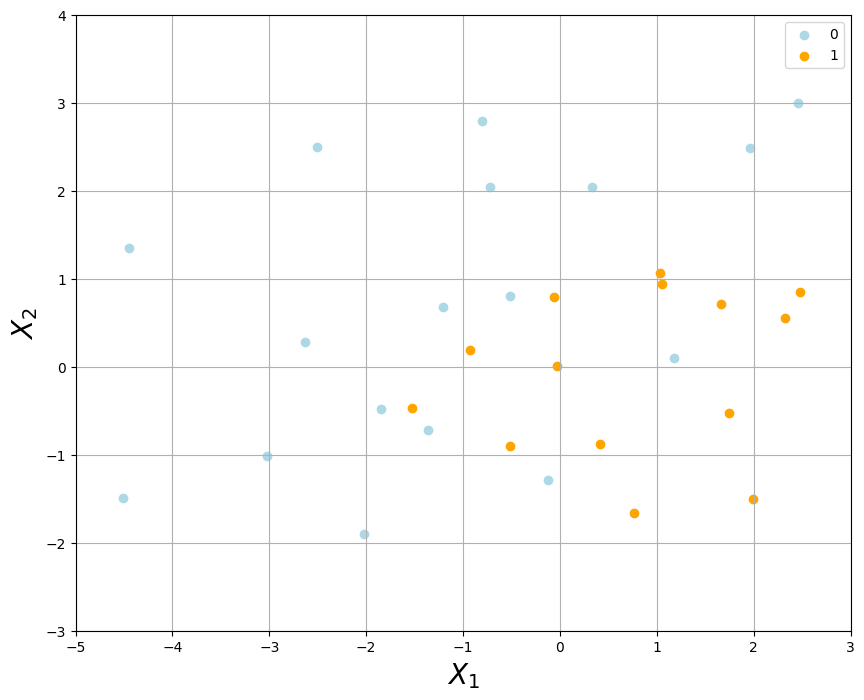

In [3]:
# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(X[y==0,0], X[y==0,1], color='lightblue', label='0', marker='o')
plt.scatter(X[y==1,0], X[y==1,1], color='orange', label='1', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-5, 3, -3, 4])
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

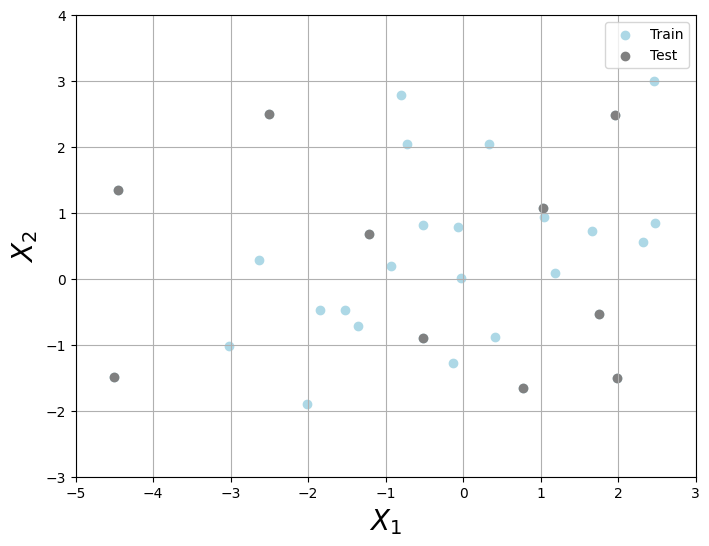

In [4]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:,0], X_train[:,1], color='lightblue', label='Train', marker='o')
plt.scatter(X_test[:,0], X_test[:,1], color='grey', label='Test', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-5, 3, -3, 4])
plt.legend(loc='upper right')

# Show grid
plt.grid(True)

# Display the plot
plt.show()

[[ 0.8991887  -0.80574646]] [0.16573918]


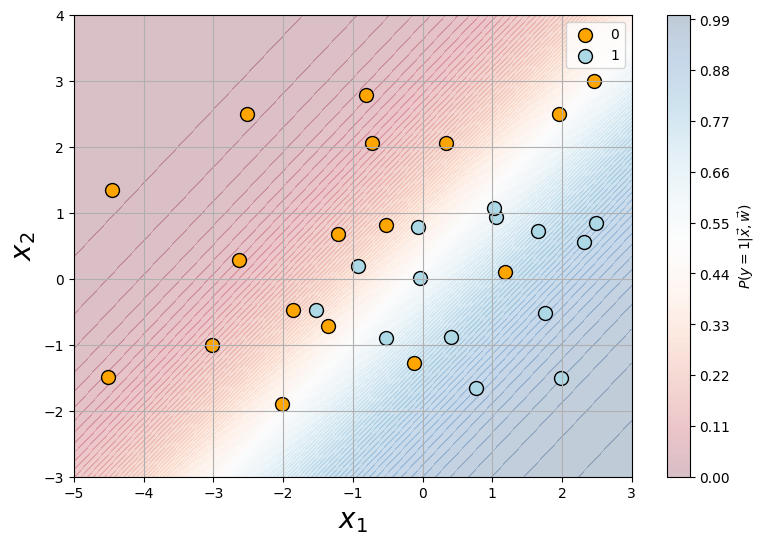

In [5]:
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

model = LogisticRegression()
model.fit(X_train, y_train)

# Define the mesh grid for the background colors
x_min, x_max = -5, 3
y_min, y_max = -3, 4
xx, yy = np.meshgrid(np.arange(x_min, x_max+0.1, 0.1),
                     np.arange(y_min, y_max+0.1, 0.1))


# Calculate probabilities for the grid points
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# Plot the probability heatmap
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=100, cmap='RdBu', alpha=0.25)
plt.colorbar(label='$P(y=1|\\vec{x},\\vec{w})$')

print(model.coef_, model.intercept_)

# Plot the data points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='orange', marker='o', edgecolor='k', s=100, label="0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='lightblue', marker='o', edgecolor='k', s=100, label="1")

plt.axis([-5, 3, -3, 4])

# Adding labels and legend
plt.xlabel("$x_1$", fontsize=20)
plt.ylabel("$x_2$", fontsize=20)
plt.legend(loc='upper right')
plt.grid()
# plt.title("Decision Boundary with Probability Heatmap")
plt.show()

-5.766659989393245 5.766830138634794
[[ 5.48167439 -4.91099564  0.48367732 -5.76665999 -0.64350064  2.56691749
  -5.75592049  0.10006931 -5.23031169  5.76683014  1.013756    3.85455047
   1.85155959 -1.57200155  0.31727416 -0.83751228]] [6.71062832]
Cross-validation scores: [0.14285714 0.66666667 0.66666667 0.33333333 0.83333333]
Average cross-validation score: 0.5285714285714286


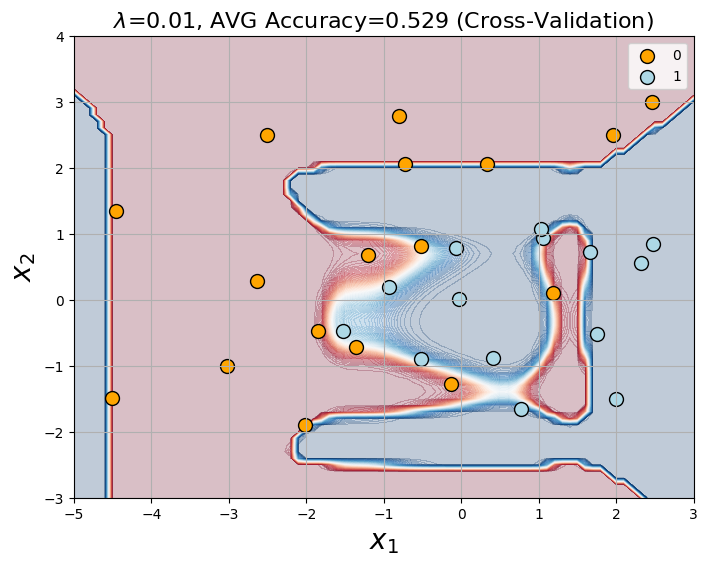

-5.766659989393245 5.766830138634794


In [45]:
#from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score, KFold

def generate_polynomial_features(X, degree):

    n_samples, n_features = X.shape
    Xp = X.copy()  # Start with the original features

    # Loop through each degree and each feature to create powers without interaction terms
    for d in range(2, degree + 1):
        for i in range(n_features):
            # Generate the d-th power for each feature individually and add to Xp
            Xp = np.hstack((Xp, (X[:, i] ** d).reshape(-1, 1)))

    return Xp


degree = 8
#poly = PolynomialFeatures(degree, include_bias=False)
# Xp_train = poly.fit_transform(X_train)
Xp_train = generate_polynomial_features(X_train, degree)
# Xp_test = poly.transform(X_test)
Xp_test = generate_polynomial_features(X_train, degree)

#scaler = StandardScaler()
#scaler.fit(Xp_train)
#Xp_train = scaler.transform(Xp_train)
#Xp_test = scaler.transform(Xp_test)
ld = 10**-2
model = LogisticRegression(penalty="l2", C=1/ld, max_iter=10000)
model.fit(Xp_train, y_train)

print(model.coef_.min(), model.coef_.max())
print(model.coef_, model.intercept_)

# Define the mesh grid for the background colors
x_min, x_max = -5, 3
y_min, y_max = -3, 4
xx, yy = np.meshgrid(np.arange(x_min, x_max+0.1, 0.1),
                     np.arange(y_min, y_max+0.1, 0.1))


# Calculate probabilities for the grid points
#Z = model.predict_proba(scaler.transform(poly.transform(np.c_[xx.ravel(), yy.ravel()])))[:, 1]
#Z = model.predict_proba(poly.transform(np.c_[xx.ravel(), yy.ravel()]))[:, 1]
Z = model.predict_proba(generate_polynomial_features(np.c_[xx.ravel(), yy.ravel()], degree))[:, 1]
#Z = model.predict_proba(scaler.transform(generate_polynomial_features(np.c_[xx.ravel(), yy.ravel()], degree)))[:, 1]
Z = Z.reshape(xx.shape)

# Plot the probability heatmap
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=100, cmap='RdBu', alpha=0.25)
#plt.colorbar(label='$P(y=1|\\vec{x},\\vec{w})$')


# Plot the data points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='orange', marker='o', edgecolor='k', s=100, label="0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='lightblue', marker='o', edgecolor='k', s=100, label="1")

plt.axis([-5, 3, -3, 4])

# Perform 5-fold cross-validation
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=42)  # Set shuffle=True to randomize the data

# Perform cross-validation
scores = cross_val_score(model, Xp_train, y_train, cv=cv)

# Print individual scores and average score
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

# Adding labels and legend
plt.xlabel("$x_1$", fontsize=20)
plt.ylabel("$x_2$", fontsize=20)
plt.legend(loc='upper right')
plt.grid()
title = "$\lambda$" + "=" + str(ld) + ", AVG Accuracy=" + str(np.round(scores.mean(), 3)) + " (Cross-Validation)"
plt.title(title, fontsize=16)
plt.show()

print(model.coef_.min(), model.coef_.max())

In [ ]:
import numpy as np
import pandas as pd

# Sample data: 2 features, x1 and x2
data = {'x1': [1, 2, 3], 'x2': [4, 5, 6]}
df = pd.DataFrame(data)

# Define the polynomial degree
degree = 3

# Generate polynomial features without interaction terms
for feature in df.columns:
    for d in range(2, degree + 1):  # Start from degree 2 as degree 1 is the original feature
        df[f'{feature}^{d}'] = df[feature] ** d

print(df)


array([[-4. , -4. ],
       [-3.9, -4. ],
       [-3.8, -4. ],
       ...,
       [ 3.8,  4. ],
       [ 3.9,  4. ],
       [ 4. ,  4. ]])

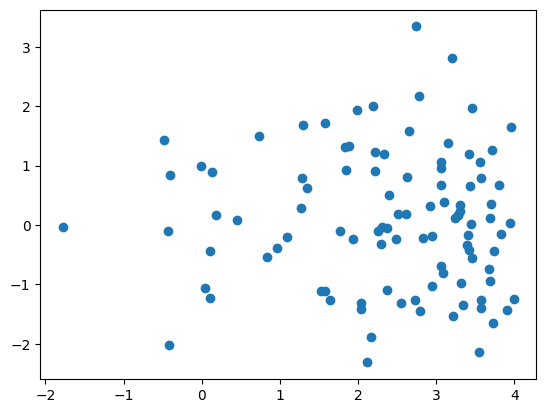

In [ ]:
(x-4)**2 + y**2 = 0
for i in range(len(X)) :
  X[i] = X[i] if X[i] <= 4 else X[i] - 2*(X[i]-4)
Y = 0 + np.random.randn(100, 1)

plt.scatter(X, Y)

X = 4 + 2*np.random.randn(100, 1)
for i in range(len(X)) :
  X[i] = X[i] if X[i] <= 4 else X[i] - 2*(X[i]-4)
Y = 0 + np.random.randn(100, 1)

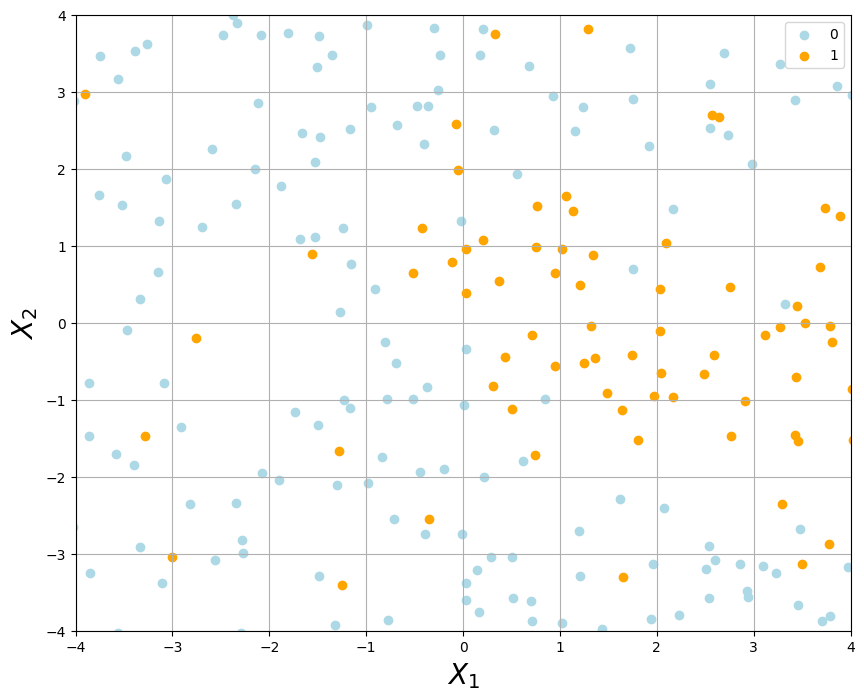

In [ ]:
x_min, x_max = -4, 4
y_min, y_max = -4, 4
xx, yy = np.meshgrid(np.arange(x_min, x_max+0.1, 0.25),
                     np.arange(y_min, y_max+0.1, 0.25))

X = np.c_[xx.ravel(), yy.ravel()]

y = np.zeros(X.shape[0])
for i in range(X.shape[0]) :
    y[i] = 1 if (0.25*(X[i][0]-4)**2 + 0.75*X[i][1]**2 - 5) <= 0 else 0

indices = []
for i in range(len(y)) :
    if np.random.rand(1) < 0.2 :
        indices.append(i)

X = X[indices]
y = y[indices]

X= X + np.random.normal(0, 0.1, size=(X.shape[0], X.shape[1]))

for i in range(len(y)) :
    if np.random.rand(1) < 0.1 :
        y[i] = 1 if y[i] == 0 else 0
             # Plotting
plt.figure(figsize=(10, 8))
plt.scatter(X[y==0,0], X[y==0,1], color='lightblue', label='0', marker='o')
plt.scatter(X[y==1,0], X[y==1,1], color='orange', label='1', marker='o')

# Adding labels and legend
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.grid()
plt.legend()


In [ ]:
data = pd.DataFrame(data=np.hstack((X,y.reshape(-1,1))), columns=['x1', 'x2', 'y'])

In [ ]:
data.to_csv("logreg_data.csv", index=False)

In [ ]:
np.random.rand(1)

array([0.28351034])

In [ ]:
https://drive.google.com/file/d/1uUWeifwQmswW24wC6Exh0M_7IhwdI28p/view?usp=sharing

In [ ]:
import numpy as np
from scipy.special import expit  # Optimized sigmoid function

def compute_gradient(X, y, weights):
    """
    Compute the gradient of the log-likelihood for logistic regression.

    Parameters:
    - X: Feature matrix (m x n)
    - y: Labels (m x 1)
    - weights: Current weights (n x 1)

    Returns:
    - gradients: Gradient vector (n x 1)
    """
    predictions = expit(X @ weights)  # Predicted probabilities using sigmoid function
    errors = y - predictions           # Error between actual and predicted
    gradients = X.T @ errors / X.shape[0]  # Average gradient

    return gradients

def gradient_descent_logistic(X, y, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
    """
    Perform gradient descent optimization for logistic regression.

    Parameters:
    - X: Feature matrix with bias term (m x n)
    - y: Labels (m x 1)
    - learning_rate: Step size for weight updates
    - max_iterations: Maximum number of iterations
    - tolerance: Convergence threshold for gradient magnitudes

    Returns:
    - weights: Optimized weights (n x 1)
    """
    # Initialize weights
    weights = np.zeros((X.shape[1], 1))

    for iteration in range(max_iterations):
        # Compute gradient
        gradients = compute_gradient(X, y, weights)

        # Update weights
        weights += learning_rate * gradients

        # Check for convergence
        if np.linalg.norm(gradients) < tolerance:
            print(f"Converged after {iteration} iterations.")
            break

    return weights

def Logistic_Regress(new_point, data_points, labels, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
    """
    Logistic Regression function that trains the model using gradient descent
    and predicts the probability for a new data point.

    Parameters:
    - new_point: New data point (1D array)
    - data_points: Training feature matrix (m x n)
    - labels: Training labels (m x 1)

    Returns:
    - probability: Predicted probability of the positive class for new_point
    """
    # Step 1: Add bias term (column of ones) to data_points
    X = np.hstack([np.ones((data_points.shape[0], 1)), data_points])

    # Step 2: Train the model using gradient descent
    weights = gradient_descent_logistic(X, labels, learning_rate, max_iterations, tolerance)

    # Step 3: Add bias term to new_point
    x = np.hstack([1, new_point])

    # Step 4: Predict the probability for new_point
    probability = expit(x @ weights)

    # Return the predicted probability
    return probability

# Example usage
# Generate random data_points and labels for demonstration
m, n = 100, 2  # Example dimensions
np.random.seed(0)
data_points = np.hstack((1.5+np.random.randn(m, 1), -1.5+np.random.randn(m, 1)))
data_points = np.vstack((data_points, np.hstack((-1.5+np.random.randn(m, 1), 1.5+np.random.randn(m, 1)))))
labels = np.hstack((np.zeros(100), np.ones(100))).T.reshape((-1,1))

# Define a new data point
new_point = np.array([1, -1])  # Example new point without bias term

# Predict the probability for new_point
learning_rate = 0.1
max_iterations = 1000
tolerance = 1e-6
probability = Logistic_Regress(new_point, data_points, labels, learning_rate, max_iterations, tolerance)
print(f"Predicted probability for new point: {probability}")


Predicted probability for new point: [0.00691733]


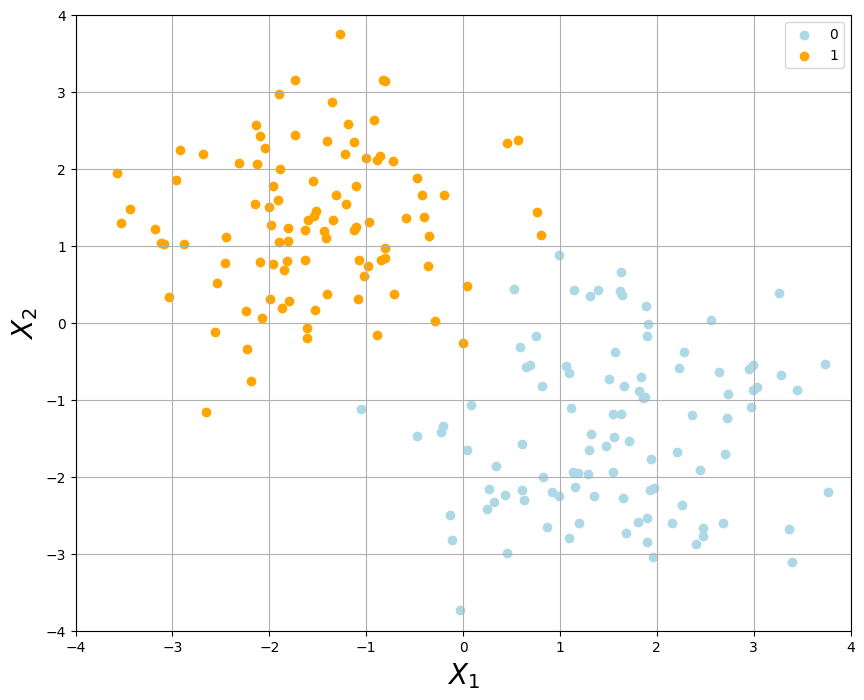

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
plt.scatter(data_points[labels[:,0]==0,0], data_points[labels[:,0]==0,1], color='lightblue', label='0', marker='o')
plt.scatter(data_points[labels[:,0]==1,0], data_points[labels[:,0]==1,1], color='orange', label='1', marker='o')
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([-4, 4, -4, 4])
plt.legend()
plt.grid()
plt.show()

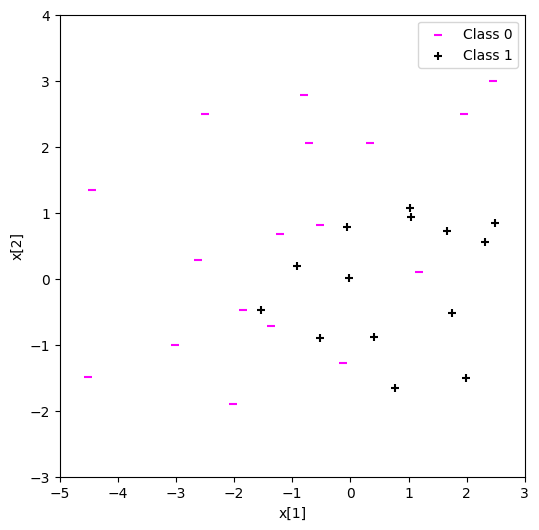

In [1]:
import matplotlib.pyplot as plt

# Class 0 data points (17 points)
class_0 = [
    (-1.85, -0.475), (-1.36, -0.720), (-3.02, -1.01), (-4.51, -1.49), (2.46, 3.00),
    (-0.804, 2.79), (-2.51, 2.50), (1.96, 2.49), (-0.720, 2.05), (0.330, 2.05),
    (-4.45, 1.35), (-0.517, 0.810), (-1.21, 0.678), (-2.63, 0.281), (1.18, 0.0962),
    (-0.127, -1.28), (-2.02, -1.90)
]

# Class 1 data points (14 points)
class_1 = [
    (-0.927, 0.191), (0.767, -1.66), (-0.0631, 0.789), (0.411, -0.877), (-0.520, -0.898),
    (1.99, -1.50), (1.66, 0.719), (1.75, -0.525), (2.48, 0.851), (-0.0292, 0.0118),
    (-1.53, -0.472), (1.05, 0.942), (1.03, 1.07), (2.32, 0.557)
]

# Separate x and y coordinates for Class 0
x0, y0 = zip(*class_0)

# Separate x and y coordinates for Class 1
x1, y1 = zip(*class_1)

# Create the plot
plt.figure(figsize=(6, 6))
plt.scatter(x0, y0, color='magenta', marker='_', label='Class 0')
plt.scatter(x1, y1, color='black', marker='+', label='Class 1')

# Set the plot limits
plt.xlim(-5, 3)
plt.ylim(-3, 4)

# Label the axes
plt.xlabel("x[1]")
plt.ylabel("x[2]")

# Add legend
plt.legend()

# Display the plot
plt.show()


In [4]:
import pandas as pd

# Data points for Class 0
class_0_data = [
    (-1.85, -0.475), (-1.36, -0.720), (-3.02, -1.01), (-4.51, -1.49), (2.46, 3.00),
    (-0.804, 2.79), (-2.51, 2.50), (1.96, 2.49), (-0.720, 2.05), (0.330, 2.05),
    (-4.45, 1.35), (-0.517, 0.810), (-1.21, 0.678), (-2.63, 0.281), (1.18, 0.0962),
    (-0.127, -1.28), (-2.02, -1.90)
]

# Data points for Class 1
class_1_data = [
    (-0.927, 0.191), (0.767, -1.66), (-0.0631, 0.789), (0.411, -0.877), (-0.520, -0.898),
    (1.99, -1.50), (1.66, 0.719), (1.75, -0.525), (2.48, 0.851), (-0.0292, 0.0118),
    (-1.53, -0.472), (1.05, 0.942), (1.03, 1.07), (2.32, 0.557)
]

# Combine data points and labels
data = class_0_data + class_1_data
labels = [0] * len(class_0_data) + [1] * len(class_1_data)

# Create DataFrame
df = pd.DataFrame(data, columns=['x1', 'x2'])
df['y'] = labels

# Display the DataFrame
print(df)


        x1      x2  y
0  -1.8500 -0.4750  0
1  -1.3600 -0.7200  0
2  -3.0200 -1.0100  0
3  -4.5100 -1.4900  0
4   2.4600  3.0000  0
5  -0.8040  2.7900  0
6  -2.5100  2.5000  0
7   1.9600  2.4900  0
8  -0.7200  2.0500  0
9   0.3300  2.0500  0
10 -4.4500  1.3500  0
11 -0.5170  0.8100  0
12 -1.2100  0.6780  0
13 -2.6300  0.2810  0
14  1.1800  0.0962  0
15 -0.1270 -1.2800  0
16 -2.0200 -1.9000  0
17 -0.9270  0.1910  1
18  0.7670 -1.6600  1
19 -0.0631  0.7890  1
20  0.4110 -0.8770  1
21 -0.5200 -0.8980  1
22  1.9900 -1.5000  1
23  1.6600  0.7190  1
24  1.7500 -0.5250  1
25  2.4800  0.8510  1
26 -0.0292  0.0118  1
27 -1.5300 -0.4720  1
28  1.0500  0.9420  1
29  1.0300  1.0700  1
30  2.3200  0.5570  1


In [5]:
# Save to CSV
df.to_csv("logistic_regression_data.csv", index=False)


In [45]:

import numpy as np

def generate_polynomial_features(X, degree):
    """
    Generate polynomial features for each individual feature without interaction terms.

    Parameters:
    - X (numpy array): Input array with shape (n_samples, n_features).
    - degree (int): The maximum degree of the polynomial features.

    Returns:
    - Xp (numpy array): Transformed array with polynomial features, shape (n_samples, n_new_features).
    """
    n_samples, n_features = X.shape
    Xp = X.copy()  # Start with the original features

    # Loop through each degree and each feature to create powers without interaction terms
    for d in range(2, degree + 1):
        for i in range(n_features):
            # Generate the d-th power for each feature individually and add to Xp
            Xp = np.hstack((Xp, (X[:, i] ** d).reshape(-1, 1)))

    return Xp

# Example usage
X = np.array([[1, 2], [3, 4], [5, 6]])
degree = 3
Xp = generate_polynomial_features(X, degree)
print(Xp)

[[  1   2   1   4   1   8]
 [  3   4   9  16  27  64]
 [  5   6  25  36 125 216]]
